# Forecasting Methodology (Step-by-Step)

# A. Data Ingestion & Structuring
	• Load daily time-series data (2023–2025)
	• Convert Date to datetime format
	• Ensure chronological ordering
	• Create a complete daily index

In [1]:
#IMPORT LIBRARIES
import pandas as pd
import numpy as np
import seaborn as sns

# 1. Load daily time-series data (2023–2025)

In [2]:
# LOAD THE DATASET
hs = pd.read_csv("HHS_Unaccompanied_Alien_Children_Program.csv")
hs

,Date,Children apprehended and placed in CBP custody*,Children in CBP custody,Children transferred out of CBP custody,Children in HHS Care,Children discharged from HHS Care
0,12/21/2025,6,18,11,"2,484",14
1,12/18/2025,11,50,6,"2,472",16
2,12/17/2025,7,31,11,"2,481",10
3,12/16/2025,8,54,15,"2,468",9
4,12/15/2025,11,42,9,"2,470",7
...,...,...,...,...,...,...
715,01/25/2023,20,22,41,"7,538",180
716,01/24/2023,47,42,47,"7,433",175
717,01/23/2023,32,50,39,"7,280",181
718,01/22/2023,32,49,39,"7,122",227


In [3]:
hs.columns

Index(['Date', 'Children apprehended and placed in CBP custody*',
       'Children in CBP custody', 'Children transferred out of CBP custody',
       'Children in HHS Care', 'Children discharged from HHS Care'],
      dtype='object')

In [4]:
hs.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 720 entries, 0 to 719
Data columns (total 6 columns):
 #   Column                                           Non-Null Count  Dtype 
---  ------                                           --------------  ----- 
 0   Date                                             720 non-null    object
 1   Children apprehended and placed in CBP custody*  720 non-null    int64 
 2   Children in CBP custody                          720 non-null    int64 
 3   Children transferred out of CBP custody          720 non-null    int64 
 4   Children in HHS Care                             720 non-null    object
 5   Children discharged from HHS Care                720 non-null    int64 
dtypes: int64(4), object(2)
memory usage: 33.9+ KB


In [5]:
hs.describe()

,Children apprehended and placed in CBP custody*,Children in CBP custody,Children transferred out of CBP custody,Children discharged from HHS Care
count,720.000000,720.000000,720.000000,720.000000
mean,93.523611,171.494444,128.668056,173.406944
std,72.646625,126.354965,97.322012,125.702841
min,0.000000,7.000000,0.000000,0.000000
25%,12.000000,36.000000,14.000000,19.750000
50%,99.000000,193.000000,157.000000,181.000000
75%,147.250000,263.250000,199.250000,267.000000
max,333.000000,531.000000,440.000000,505.000000


# 2. Convert Date to datetime format

In [6]:
hs.head(5)

,Date,Children apprehended and placed in CBP custody*,Children in CBP custody,Children transferred out of CBP custody,Children in HHS Care,Children discharged from HHS Care
0,12/21/2025,6,18,11,"2,484",14
1,12/18/2025,11,50,6,"2,472",16
2,12/17/2025,7,31,11,"2,481",10
3,12/16/2025,8,54,15,"2,468",9
4,12/15/2025,11,42,9,"2,470",7


In [7]:
hs.tail(5)

,Date,Children apprehended and placed in CBP custody*,Children in CBP custody,Children transferred out of CBP custody,Children in HHS Care,Children discharged from HHS Care
715,01/25/2023,20,22,41,"7,538",180
716,01/24/2023,47,42,47,"7,433",175
717,01/23/2023,32,50,39,"7,280",181
718,01/22/2023,32,49,39,"7,122",227
719,01/12/2023,33,53,34,"6,566",436


In [8]:
hs.dtypes

Date                                               object
Children apprehended and placed in CBP custody*     int64
Children in CBP custody                             int64
Children transferred out of CBP custody             int64
Children in HHS Care                               object
Children discharged from HHS Care                   int64
dtype: object

In [9]:
hs["Children in HHS Care"] = (hs["Children in HHS Care"].astype(str).str.replace(",", "").str.strip())

In [10]:
hs["Children in HHS Care"] = pd.to_numeric(hs["Children in HHS Care"], errors="coerce")

In [11]:
hs.head(5)

,Date,Children apprehended and placed in CBP custody*,Children in CBP custody,Children transferred out of CBP custody,Children in HHS Care,Children discharged from HHS Care
0,12/21/2025,6,18,11,2484,14
1,12/18/2025,11,50,6,2472,16
2,12/17/2025,7,31,11,2481,10
3,12/16/2025,8,54,15,2468,9
4,12/15/2025,11,42,9,2470,7


In [12]:
# Convert date column to datetime
hs['Date'] = pd.to_datetime(hs['Date'] , format="%m/%d/%Y")

In [13]:
hs.dtypes

Date                                               datetime64[ns]
Children apprehended and placed in CBP custody*             int64
Children in CBP custody                                     int64
Children transferred out of CBP custody                     int64
Children in HHS Care                                        int64
Children discharged from HHS Care                           int64
dtype: object

In [14]:
hs = hs.set_index('Date')

In [15]:
hs.head(5)

,Children apprehended and placed in CBP custody*,Children in CBP custody,Children transferred out of CBP custody,Children in HHS Care,Children discharged from HHS Care
Date,,,,,
2025-12-21,6,18,11,2484,14
2025-12-18,11,50,6,2472,16
2025-12-17,7,31,11,2481,10
2025-12-16,8,54,15,2468,9
2025-12-15,11,42,9,2470,7


In [16]:
hs.dtypes

Children apprehended and placed in CBP custody*    int64
Children in CBP custody                            int64
Children transferred out of CBP custody            int64
Children in HHS Care                               int64
Children discharged from HHS Care                  int64
dtype: object

In [17]:
# Rename the columns:
hs = hs.rename(columns={ 
     'Children apprehended and placed in CBP custody*' : 'Apprehended' , 
     'Children in CBP custody' : 'CBP_custody',
     'Children transferred out of CBP custody' : 'Transfers' ,
     'Children in HHS Care' : 'HHS_care' ,
     'Children discharged from HHS Care' : 'Discharges'
})

In [18]:
hs.head(2)

,Apprehended,CBP_custody,Transfers,HHS_care,Discharges
Date,,,,,
2025-12-21,6,18,11,2484,14
2025-12-18,11,50,6,2472,16


In [19]:
print("CBP missing:", hs['CBP_custody'].isnull().sum())
print("Transfers missing:", hs['Transfers'].isnull().sum())
print("HHS missing:", hs['HHS_care'].isnull().sum())
print("Discharges:", hs['Discharges'].isnull().sum())

CBP missing: 0
Transfers missing: 0
HHS missing: 0
Discharges: 0


# 3. Ensure chronological ordering

In [20]:
hs = hs.sort_index()
hs.head(5)

,Apprehended,CBP_custody,Transfers,HHS_care,Discharges
Date,,,,,
2023-01-12,33,53,34,6566,436
2023-01-22,32,49,39,7122,227
2023-01-23,32,50,39,7280,181
2023-01-24,47,42,47,7433,175
2023-01-25,20,22,41,7538,180


In [21]:
# Check if Data is Chronologically Ordered
hs.index.is_monotonic_increasing

True

# 4. Create a complete daily index

In [22]:
hs.shape

(720, 5)

In [23]:
full_index = pd.date_range(start=hs.index.min(), end=hs.index.max(), freq='D')

In [24]:
hs = hs.reindex(full_index)
hs.shape

(1075, 5)

# B. Data Quality & Validation

# Derived predictive features include:
     •Identify missing or duplicated dates
     •Validate logical constraints:
           Transfers ≤ CBP custody
           Discharges ≤ HHS care
     •Flag reporting anomalies for transparency

# 1. Identify missing or duplicated dates

In [25]:
type(hs.index)

pandas.core.indexes.datetimes.DatetimeIndex

In [26]:
hs.index.is_monotonic_increasing

True

In [27]:
# Identify Duplicated dates
print("Number of duplicated rows:" , hs.index.duplicated().sum())

Number of duplicated rows: 0


In [28]:
#Identify Missing Dates
fd = pd.date_range(start=hs.index.min(), end=hs.index.max(), freq='D')

In [29]:
md = fd.difference(hs.index)
print("Missing Dates : ", len(md))

Missing Dates :  0


# 2. Validate logical constraints:
       Transfers ≤ CBP_custody
       Discharges ≤ HHS_care

In [30]:
# Stock variables
hs['CBP_custody'] = hs['CBP_custody'].fillna(method='ffill')
hs['HHS_care'] = hs['HHS_care'].fillna(method='ffill')

# Flow variables
hs['Transfers'] = hs['Transfers'].fillna(0)
hs['Discharges'] = hs['Discharges'].fillna(0)

C:\Users\HP\AppData\Local\Temp\ipykernel_1576\238789096.py:2: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  hs['CBP_custody'] = hs['CBP_custody'].fillna(method='ffill')
C:\Users\HP\AppData\Local\Temp\ipykernel_1576\238789096.py:3: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  hs['HHS_care'] = hs['HHS_care'].fillna(method='ffill')


# Validate logical constraints: Transfers ≤ CBP custody

In [31]:
invalid_transfers = hs[hs['Transfers'] > hs['CBP_custody']]
print("Invalid Transfer Records:", len(invalid_transfers))

Invalid Transfer Records: 86


# There are total 86 records which voilates the rule

In [32]:
invalid_transfers.head(5)

,Apprehended,CBP_custody,Transfers,HHS_care,Discharges
2023-01-24,47.0,42.0,47.0,7433.0,175.0
2023-01-25,20.0,22.0,41.0,7538.0,180.0
2023-02-02,15.0,13.0,23.0,7879.0,298.0
2023-02-22,107.0,215.0,230.0,7978.0,232.0
2023-02-23,101.0,162.0,178.0,7914.0,386.0


# This show rows in which Children Transferred out of CBP custody exceed No. of Children present in CBP custody.

# Validate logical constraints: Discharge ≤ HHS Care

In [33]:
invalid_discharge = hs[hs['Discharges'] > hs['HHS_care']]
print("Invalid Discharge Records:", len(invalid_discharge))

Invalid Discharge Records: 0


# This shows that no such rows are present in datset where the No. of children discharged fromm HHS care exceeds The No. of children present in HHS Care

# 3. Flag reporting anomalies for transparency

In [34]:
hs["invalid_transfer_anomaly"] = hs['Transfers'] > hs['CBP_custody']
hs.head(5)

,Apprehended,CBP_custody,Transfers,HHS_care,Discharges,invalid_transfer_anomaly
2023-01-12,33.0,53.0,34.0,6566.0,436.0,False
2023-01-13,NaN,53.0,0.0,6566.0,0.0,False
2023-01-14,NaN,53.0,0.0,6566.0,0.0,False
2023-01-15,NaN,53.0,0.0,6566.0,0.0,False
2023-01-16,NaN,53.0,0.0,6566.0,0.0,False


# O/P is False = No voilation of rule & TRUE = Voilation of rule.

In [35]:
hs["invalid_discharge_anamoly"] = hs['Discharges'] > hs['HHS_care']
hs.head(5)

,Apprehended,CBP_custody,Transfers,HHS_care,Discharges,invalid_transfer_anomaly,invalid_discharge_anamoly
2023-01-12,33.0,53.0,34.0,6566.0,436.0,False,False
2023-01-13,NaN,53.0,0.0,6566.0,0.0,False,False
2023-01-14,NaN,53.0,0.0,6566.0,0.0,False,False
2023-01-15,NaN,53.0,0.0,6566.0,0.0,False,False
2023-01-16,NaN,53.0,0.0,6566.0,0.0,False,False


# Discharge data is logically consistent & No anomalies detected in HHS stage

In [36]:
hs['missing_flag'] = hs[['Transfers','CBP_custody','Discharges','HHS_care']].isnull().any(axis=1)
hs.loc[hs['missing_flag'], 'status'] = 'Missing'

In [37]:
hs.head(5)

,Apprehended,CBP_custody,Transfers,HHS_care,Discharges,invalid_transfer_anomaly,invalid_discharge_anamoly,missing_flag,status
2023-01-12,33.0,53.0,34.0,6566.0,436.0,False,False,False,NaN
2023-01-13,NaN,53.0,0.0,6566.0,0.0,False,False,False,NaN
2023-01-14,NaN,53.0,0.0,6566.0,0.0,False,False,False,NaN
2023-01-15,NaN,53.0,0.0,6566.0,0.0,False,False,False,NaN
2023-01-16,NaN,53.0,0.0,6566.0,0.0,False,False,False,NaN


# C. Derived Healthcare Capacity Metrics

# Key computed metrics include:
  • Total System Load : CBP Custody + HHS Care
  • Net Daily Intake : Transfers into HHS − Discharges from HHS
  • Care Load Growth Rate : Day-over-day percentage change
  • Backlog Indicator : Sustained positive net intake over time

# 1. TOTAL SYSTEM LOAD : CBP CUSTODY + HHS CARE

In [38]:
hs["Total_System_Load"] = hs["CBP_custody"] + hs["HHS_care"]
hs.head(10)

,Apprehended,CBP_custody,Transfers,HHS_care,Discharges,invalid_transfer_anomaly,invalid_discharge_anamoly,missing_flag,status,Total_System_Load
2023-01-12,33.0,53.0,34.0,6566.0,436.0,False,False,False,NaN,6619.0
2023-01-13,NaN,53.0,0.0,6566.0,0.0,False,False,False,NaN,6619.0
2023-01-14,NaN,53.0,0.0,6566.0,0.0,False,False,False,NaN,6619.0
2023-01-15,NaN,53.0,0.0,6566.0,0.0,False,False,False,NaN,6619.0
2023-01-16,NaN,53.0,0.0,6566.0,0.0,False,False,False,NaN,6619.0
2023-01-17,NaN,53.0,0.0,6566.0,0.0,False,False,False,NaN,6619.0
2023-01-18,NaN,53.0,0.0,6566.0,0.0,False,False,False,NaN,6619.0
2023-01-19,NaN,53.0,0.0,6566.0,0.0,False,False,False,NaN,6619.0
2023-01-20,NaN,53.0,0.0,6566.0,0.0,False,False,False,NaN,6619.0
2023-01-21,NaN,53.0,0.0,6566.0,0.0,False,False,False,NaN,6619.0


# 2• Net Daily Intake : Transfers into HHS − Discharges from HHS

In [39]:
hs["Net Daily Intake"] = hs["Transfers"] - hs["Discharges"]
hs.head(10)

,Apprehended,CBP_custody,Transfers,HHS_care,Discharges,invalid_transfer_anomaly,invalid_discharge_anamoly,missing_flag,status,Total_System_Load,Net Daily Intake
2023-01-12,33.0,53.0,34.0,6566.0,436.0,False,False,False,NaN,6619.0,-402.0
2023-01-13,NaN,53.0,0.0,6566.0,0.0,False,False,False,NaN,6619.0,0.0
2023-01-14,NaN,53.0,0.0,6566.0,0.0,False,False,False,NaN,6619.0,0.0
2023-01-15,NaN,53.0,0.0,6566.0,0.0,False,False,False,NaN,6619.0,0.0
2023-01-16,NaN,53.0,0.0,6566.0,0.0,False,False,False,NaN,6619.0,0.0
2023-01-17,NaN,53.0,0.0,6566.0,0.0,False,False,False,NaN,6619.0,0.0
2023-01-18,NaN,53.0,0.0,6566.0,0.0,False,False,False,NaN,6619.0,0.0
2023-01-19,NaN,53.0,0.0,6566.0,0.0,False,False,False,NaN,6619.0,0.0
2023-01-20,NaN,53.0,0.0,6566.0,0.0,False,False,False,NaN,6619.0,0.0
2023-01-21,NaN,53.0,0.0,6566.0,0.0,False,False,False,NaN,6619.0,0.0


# O/P IS 
  +ve - > More children are entering than leaving -> Load increasing
  -ve - > More leaving -> Load decreasing
  Zero -> Stable system

# 3• Care Load Growth Rate : Day-over-day percentage change

In [40]:
# For HHS
hs["Care_Load_Growth_Rate"] = hs["HHS_care"].pct_change() * 100
hs["Care_Load_Growth_Rate"]

2023-01-12         NaN
2023-01-13    0.000000
2023-01-14    0.000000
2023-01-15    0.000000
2023-01-16    0.000000
                ...   
2025-12-17    0.526742
2025-12-18   -0.362757
2025-12-19    0.000000
2025-12-20    0.000000
2025-12-21    0.485437
Freq: D, Name: Care_Load_Growth_Rate, Length: 1075, dtype: float64

In [41]:
hs["Care_Load_Growth_Rate"] = hs["Care_Load_Growth_Rate"].fillna(0)
hs["Care_Load_Growth_Rate"]

2023-01-12    0.000000
2023-01-13    0.000000
2023-01-14    0.000000
2023-01-15    0.000000
2023-01-16    0.000000
                ...   
2025-12-17    0.526742
2025-12-18   -0.362757
2025-12-19    0.000000
2025-12-20    0.000000
2025-12-21    0.485437
Freq: D, Name: Care_Load_Growth_Rate, Length: 1075, dtype: float64

# If O/P is
  • +ve -> System Expanding
  • -ve -> System Reducing

# 4. Backlog Indicator : Sustained positive net intake over time

In [42]:
hs["Positive_Intake"] = hs["Net Daily Intake"] > 0

In [43]:
hs["Backlog_Indicator"] = hs["Positive_Intake"].rolling(7).sum()
hs.head(5)

,Apprehended,CBP_custody,Transfers,HHS_care,Discharges,invalid_transfer_anomaly,invalid_discharge_anamoly,missing_flag,status,Total_System_Load,Net Daily Intake,Care_Load_Growth_Rate,Positive_Intake,Backlog_Indicator
2023-01-12,33.0,53.0,34.0,6566.0,436.0,False,False,False,NaN,6619.0,-402.0,0.0,False,NaN
2023-01-13,NaN,53.0,0.0,6566.0,0.0,False,False,False,NaN,6619.0,0.0,0.0,False,NaN
2023-01-14,NaN,53.0,0.0,6566.0,0.0,False,False,False,NaN,6619.0,0.0,0.0,False,NaN
2023-01-15,NaN,53.0,0.0,6566.0,0.0,False,False,False,NaN,6619.0,0.0,0.0,False,NaN
2023-01-16,NaN,53.0,0.0,6566.0,0.0,False,False,False,NaN,6619.0,0.0,0.0,False,NaN


# If O/P is 
  High +ve -> System overload building
  Near Zero -> Balanced
  Negative -> System clearing backlog

# D. Trend & Temporal Analysis
1. Daily, weekly, and monthly care load trends
2. Identification of sustained high-load periods
3. Comparison across calendar periods (early vs late timeline)

# 1. Daily, weekly, and monthly care load trends

In [44]:
# DAILY TREND
daily_load = hs["Total_System_Load"]
daily_load

2023-01-12    6619.0
2023-01-13    6619.0
2023-01-14    6619.0
2023-01-15    6619.0
2023-01-16    6619.0
               ...  
2025-12-17    2512.0
2025-12-18    2522.0
2025-12-19    2522.0
2025-12-20    2522.0
2025-12-21    2502.0
Freq: D, Name: Total_System_Load, Length: 1075, dtype: float64

In [45]:
# WEEKLY TREND
weekly_load = hs["Total_System_Load"].resample("W").mean()
weekly_load

2023-01-15    6619.000000
2023-01-22    6697.857143
2023-01-29    7508.857143
2023-02-05    7835.857143
2023-02-12    7970.142857
                 ...     
2025-11-23    2392.142857
2025-11-30    2418.142857
2025-12-07    2450.285714
2025-12-14    2483.142857
2025-12-21    2516.285714
Freq: W-SUN, Name: Total_System_Load, Length: 154, dtype: float64

In [46]:
# MONTHLY TREND
monthly_load = hs["Total_System_Load"].resample("ME").mean()
monthly_load

2023-01-31     7077.950000
2023-02-28     7986.178571
2023-03-31     8191.225806
2023-04-30     8120.000000
2023-05-31     8425.580645
2023-06-30     6336.133333
2023-07-31     7041.935484
2023-08-31     9508.354839
2023-09-30    10960.633333
2023-10-31    10391.967742
2023-11-30     9904.333333
2023-12-31    11259.548387
2024-01-31     9023.677419
2024-02-29     8779.551724
2024-03-31     8740.870968
2024-04-30     7332.766667
2024-05-31     7849.032258
2024-06-30     7718.866667
2024-07-31     6544.032258
2024-08-31     6289.612903
2024-09-30     6463.166667
2024-10-31     6284.935484
2024-11-30     6190.500000
2024-12-31     6714.032258
2025-01-31     5134.645161
2025-02-28     2832.357143
2025-03-31     2190.387097
2025-04-30     2295.833333
2025-05-31     2446.838710
2025-06-30     2516.200000
2025-07-31     2215.032258
2025-08-31     2029.193548
2025-09-30     2116.900000
2025-10-31     2263.419355
2025-11-30     2360.200000
2025-12-31     2483.238095
Freq: ME, Name: Total_System

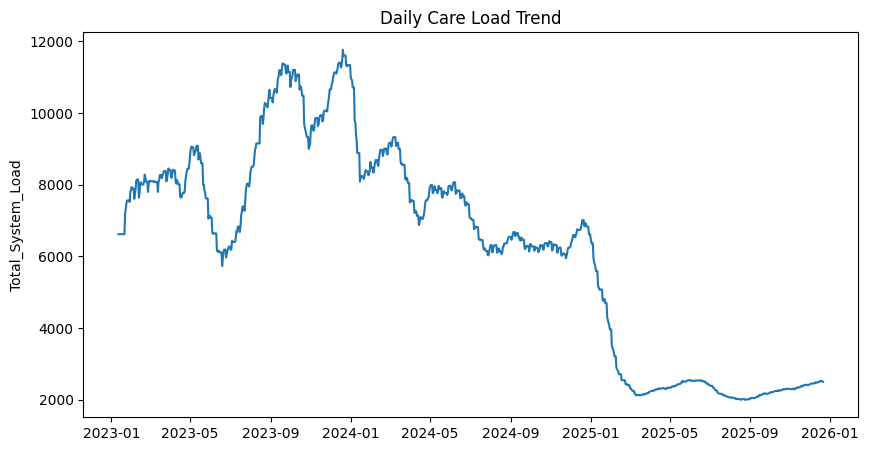

In [47]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
sns.lineplot(data=daily_load)
plt.title("Daily Care Load Trend")
plt.show()

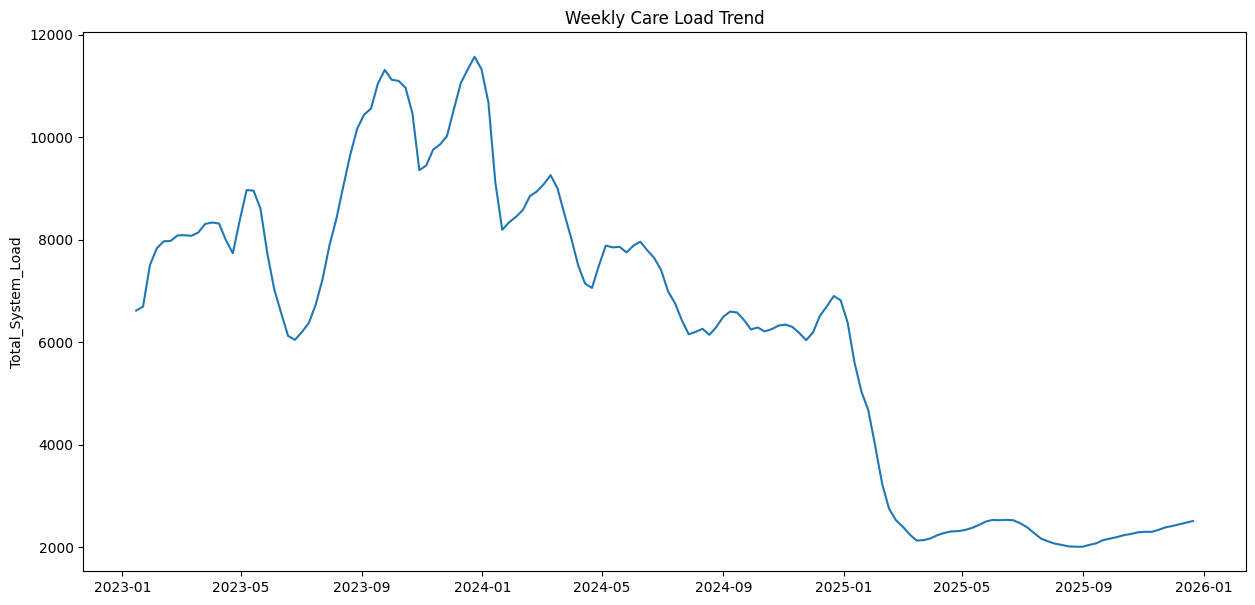

In [48]:
# FOR WEEKLY TREND
plt.figure(figsize=(15, 7))
sns.lineplot(data=weekly_load)
plt.title("Weekly Care Load Trend")
plt.show()

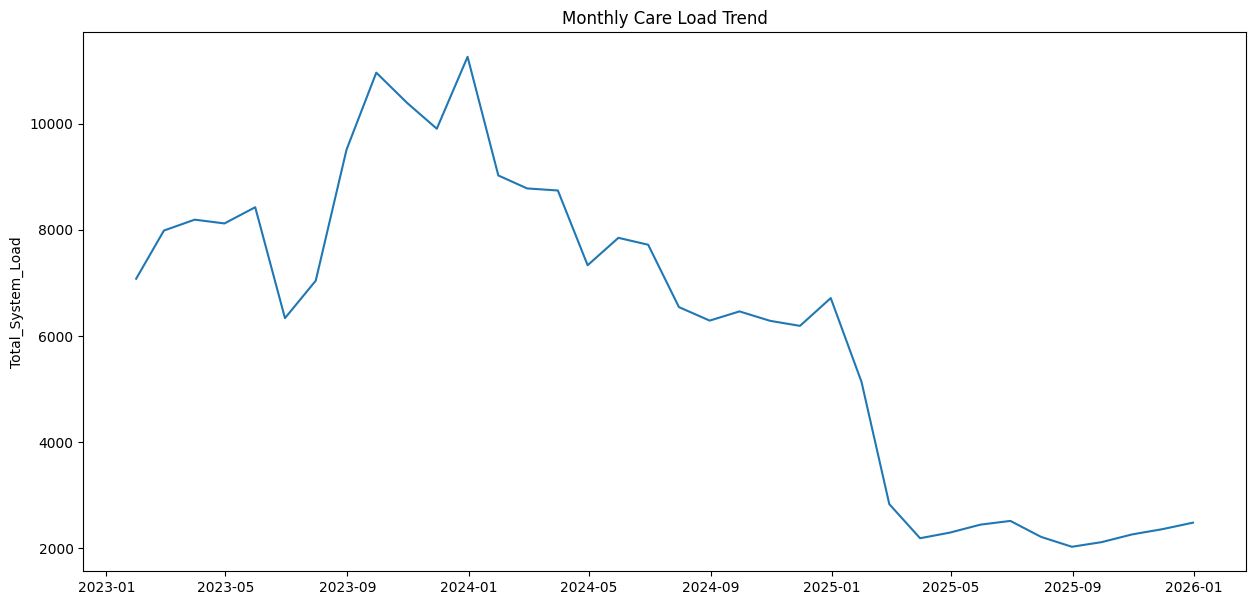

In [49]:
# FOR MONTHLY TREND
plt.figure(figsize=(15, 7))
sns.lineplot(data=monthly_load)
plt.title("Monthly Care Load Trend")
plt.show()

# Graph lines are 
   Rising -> System pressure increasing
   Falling trend -> System stabilizing
   Flat -> Balanced system

# 2. Identification of sustained high-load periods

In [50]:
# DEFINING THRESHOLD FOR TOP 25% LOAD VALUES
threshold = hs["Total_System_Load"].quantile(0.75)
hs["High_Load"] = hs["Total_System_Load"] > threshold

In [51]:
hs["Sustained_High_Load"] = (hs["High_Load"].rolling(7).sum()==7)

In [52]:
hs.head(2)

,Apprehended,CBP_custody,Transfers,HHS_care,Discharges,invalid_transfer_anomaly,invalid_discharge_anamoly,missing_flag,status,Total_System_Load,Net Daily Intake,Care_Load_Growth_Rate,Positive_Intake,Backlog_Indicator,High_Load,Sustained_High_Load
2023-01-12,33.0,53.0,34.0,6566.0,436.0,False,False,False,NaN,6619.0,-402.0,0.0,False,NaN,False,False
2023-01-13,NaN,53.0,0.0,6566.0,0.0,False,False,False,NaN,6619.0,0.0,0.0,False,NaN,False,False


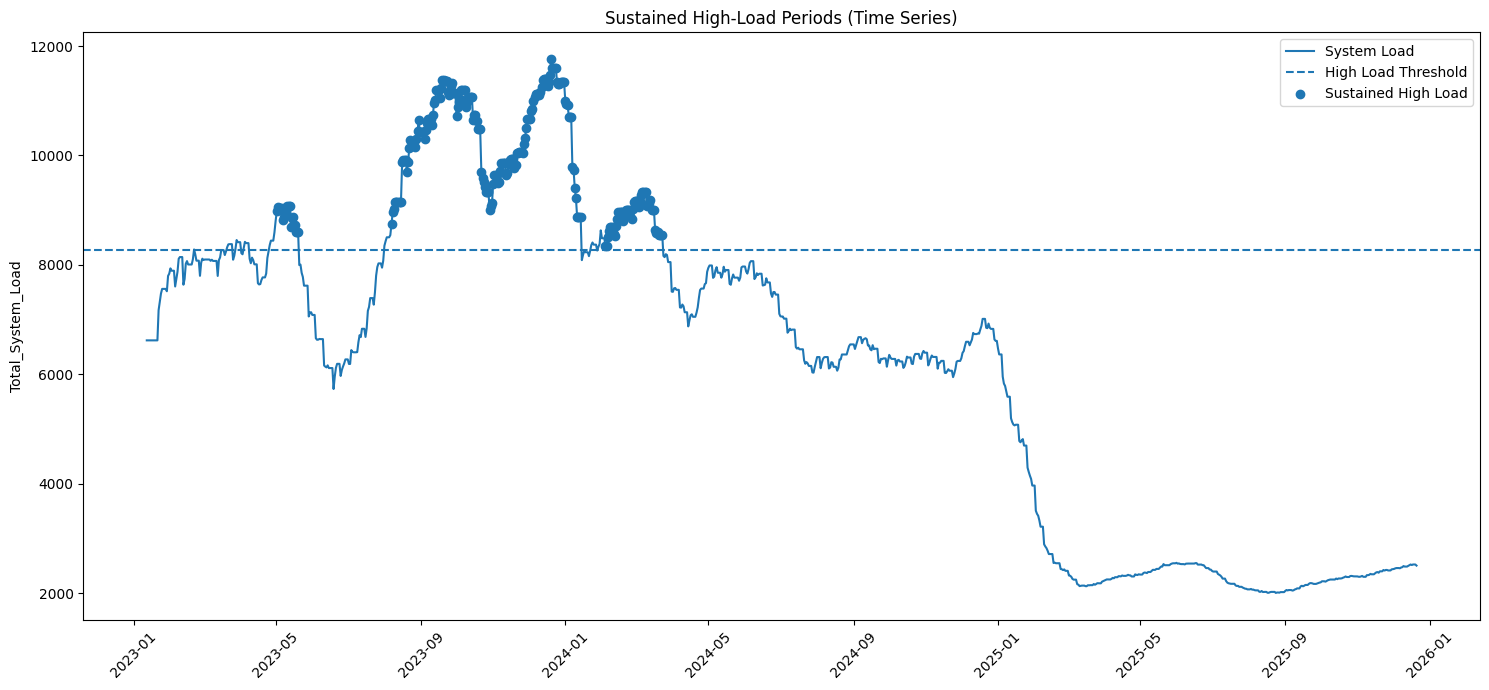

In [53]:
plt.figure(figsize=(15,7))

# Line plot (index = date automatically used)
sns.lineplot(data=hs["Total_System_Load"], label="System Load")

# Threshold line
plt.axhline(y=threshold, linestyle='--', label="High Load Threshold")

# Highlight sustained periods
plt.scatter(
    hs.index[hs["Sustained_High_Load"]],
    hs["Total_System_Load"][hs["Sustained_High_Load"]],
    label="Sustained High Load"
)

plt.xticks(rotation=45)
plt.title("Sustained High-Load Periods (Time Series)")

plt.legend()
plt.tight_layout()
plt.show()

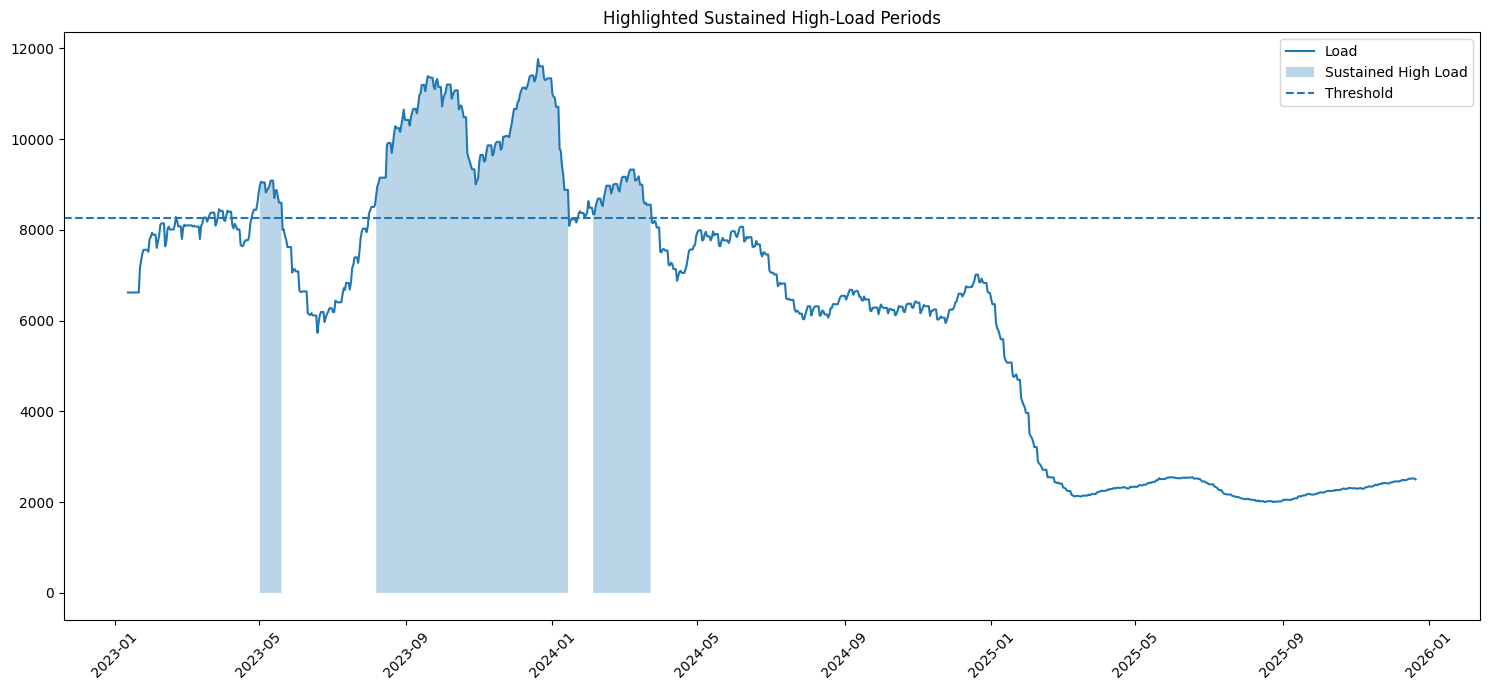

In [54]:
plt.figure(figsize=(15,7))

plt.plot(hs.index, hs["Total_System_Load"], label="Load")

# Highlight regions
plt.fill_between(
    hs.index,
    hs["Total_System_Load"],
    where=hs["Sustained_High_Load"],
    alpha=0.3,
    label="Sustained High Load"
)

plt.axhline(y=threshold, linestyle='--', label="Threshold")

plt.xticks(rotation=45)
plt.legend()
plt.title("Highlighted Sustained High-Load Periods")

plt.tight_layout()
plt.show()

# 3. Comparison across calendar periods (early vs late timeline)

In [55]:
mid_date = hs.index.min() + (hs.index.max() - hs.index.min()) / 2

early_period = hs[hs.index <= mid_date]
late_period = hs[hs.index > mid_date]

In [56]:
print("Early period load:", early_period["Total_System_Load"].mean())
print("Late period load:", late_period["Total_System_Load"].mean())

Early period load: 8621.695167286245
Late period load: 3875.420856610801


# As seen above Early > Late, it means System is improving

In [57]:
hs['Total_System_Load'].isnull().sum()

np.int64(0)

In [58]:
from scipy.stats import linregress

slope, _, _, _, _ = linregress(range(len(hs)), hs['Total_System_Load'])

print("System Trend Slope:", slope)

System Trend Slope: -7.812024546810833


In [59]:
hs["period"] = ["Early" if d <= mid_date else "Late" for d in hs.index]

In [60]:
hs.head(2)

,Apprehended,CBP_custody,Transfers,HHS_care,Discharges,invalid_transfer_anomaly,invalid_discharge_anamoly,missing_flag,status,Total_System_Load,Net Daily Intake,Care_Load_Growth_Rate,Positive_Intake,Backlog_Indicator,High_Load,Sustained_High_Load,period
2023-01-12,33.0,53.0,34.0,6566.0,436.0,False,False,False,NaN,6619.0,-402.0,0.0,False,NaN,False,False,Early
2023-01-13,NaN,53.0,0.0,6566.0,0.0,False,False,False,NaN,6619.0,0.0,0.0,False,NaN,False,False,Early


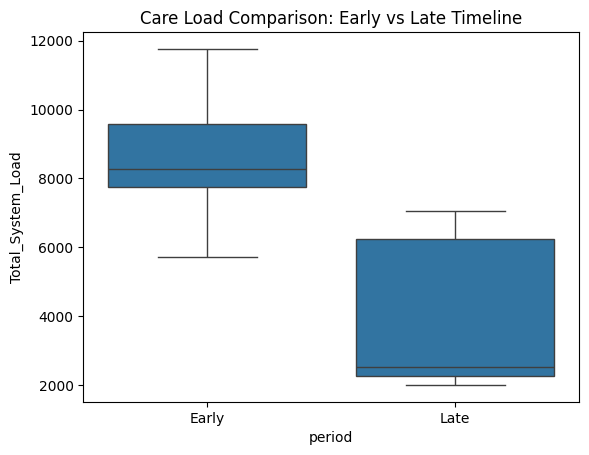

In [61]:
sns.boxplot(x="period", y="Total_System_Load", data=hs)
plt.title("Care Load Comparison: Early vs Late Timeline")
plt.show()

# E. Pressure & Stress Identification
•	Rolling averages (7-day, 14-day)
•	Variability analysis
•	Detection of prolonged strain windows

# 1. Rolling averages (7-day, 14-day) 

In [65]:
# 7-day rolling average
hs['Load_7d_avg']  = hs['Total_System_Load'].rolling(7,  min_periods=3).mean()

# 14-day rolling average
hs['Load_14d_avg'] = hs['Total_System_Load'].rolling(14, min_periods=7).mean()

In [66]:
hs["Load_7d_avg"]

2023-01-12            NaN
2023-01-13            NaN
2023-01-14    6619.000000
2023-01-15    6619.000000
2023-01-16    6619.000000
                 ...     
2025-12-17    2499.285714
2025-12-18    2504.714286
2025-12-19    2510.142857
2025-12-20    2515.571429
2025-12-21    2516.285714
Freq: D, Name: Load_7d_avg, Length: 1075, dtype: float64

In [67]:
hs["Load_14d_avg"]

2023-01-12            NaN
2023-01-13            NaN
2023-01-14            NaN
2023-01-15            NaN
2023-01-16            NaN
                 ...     
2025-12-17    2482.285714
2025-12-18    2486.928571
2025-12-19    2491.571429
2025-12-20    2496.214286
2025-12-21    2499.714286
Freq: D, Name: Load_14d_avg, Length: 1075, dtype: float64

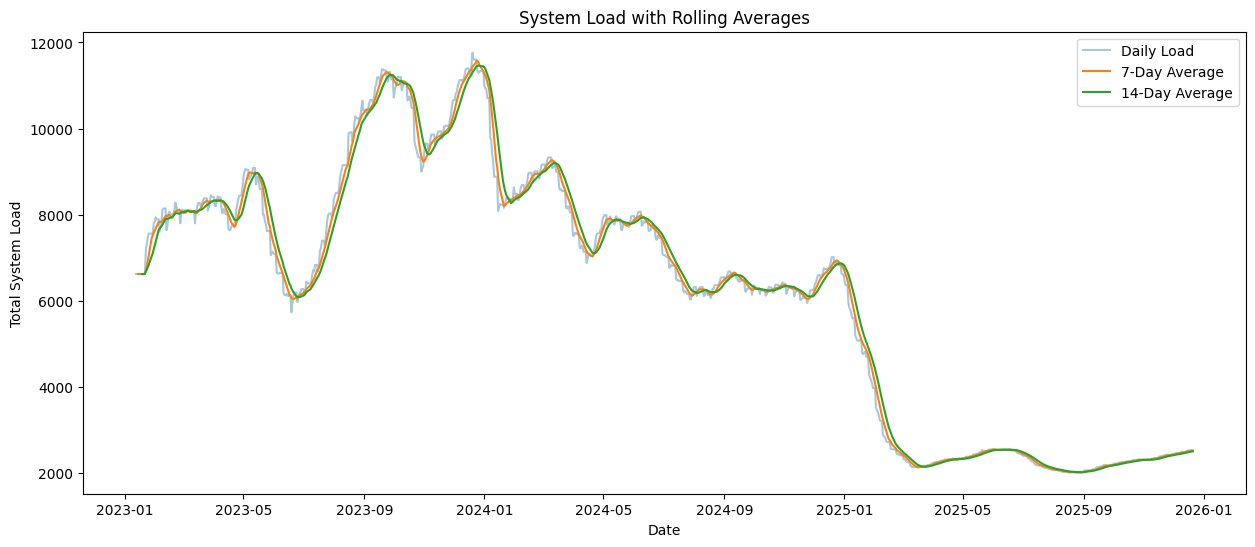

In [68]:
plt.figure(figsize=(15,6))
sns.lineplot(x=hs.index,y=hs['Total_System_Load'],label='Daily Load',alpha=0.4)
sns.lineplot(x=hs.index,y=hs['Load_7d_avg'],label='7-Day Average')
sns.lineplot(x=hs.index,y=hs['Load_14d_avg'],label='14-Day Average')
plt.title("System Load with Rolling Averages")
plt.xlabel("Date")
plt.ylabel("Total System Load")
plt.legend()
plt.show()

# 2. Variablity Analysis

In [69]:
# Rolling standard deviation
hs['Load_7d_std']  = hs['Total_System_Load'].rolling(7).std()
hs['Load_14d_std'] = hs['Total_System_Load'].rolling(14).std()

# Coefficient of Variation (scale-free)
hs['Load_7d_cv'] = hs['Load_7d_std'] / hs['Load_7d_avg']

In [70]:
hs['Load_7d_cv']

2023-01-12         NaN
2023-01-13         NaN
2023-01-14         NaN
2023-01-15         NaN
2023-01-16         NaN
                ...   
2025-12-17    0.006421
2025-12-18    0.006563
2025-12-19    0.005830
2025-12-20    0.003756
2025-12-21    0.003127
Freq: D, Name: Load_7d_cv, Length: 1075, dtype: float64

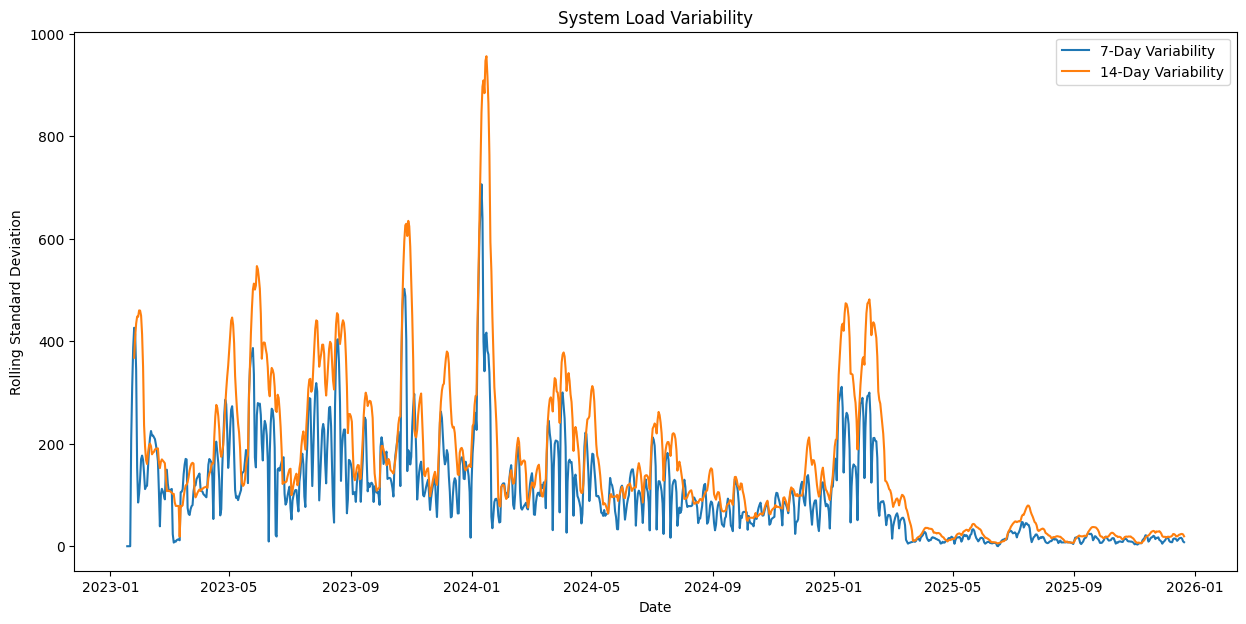

In [71]:
plt.figure(figsize=(15,7))

sns.lineplot(x=hs.index,y=hs['Load_7d_std'],label='7-Day Variability')
sns.lineplot(x=hs.index,y=hs['Load_14d_std'],label='14-Day Variability')
plt.title("System Load Variability")
plt.xlabel("Date")
plt.ylabel("Rolling Standard Deviation")
plt.legend()
plt.show()

# 3. Detection of prolonged strain windows 

In [72]:
threshold = hs["Total_System_Load"].quantile(0.75)

In [73]:
hs["High_Load"] = hs["Total_System_Load"] > threshold

In [74]:
# 7-day continuous high load
hs["Strain_7d"] = hs["High_Load"].rolling(7).sum() == 7

In [75]:
# 14-day continuous high load
hs['Strain_14d'] = hs['High_Load'].rolling(14).sum() == 14

In [76]:
hs['pressure_flag'] = ((hs['Total_System_Load'] > threshold) & (hs['Net Daily Intake'] > 0))

In [77]:
hs['Sustained_pressure_7d'] = hs['pressure_flag'].rolling(7).sum() == 7
hs['Sustained_pressure_7d']

2023-01-12    False
2023-01-13    False
2023-01-14    False
2023-01-15    False
2023-01-16    False
              ...  
2025-12-17    False
2025-12-18    False
2025-12-19    False
2025-12-20    False
2025-12-21    False
Freq: D, Name: Sustained_pressure_7d, Length: 1075, dtype: bool

In [78]:
print("High load days:", hs['High_Load'].sum())
print("7-day strain windows:", hs['Strain_7d'].sum())
print("Sustained pressure windows:", hs['Sustained_pressure_7d'].sum())

High load days: 268
7-day strain windows: 229
Sustained pressure windows: 0


In [79]:
hs['Stress_score'] = (hs['Total_System_Load'] / hs['Total_System_Load'].max())
hs['Stress_score']

2023-01-12    0.562744
2023-01-13    0.562744
2023-01-14    0.562744
2023-01-15    0.562744
2023-01-16    0.562744
                ...   
2025-12-17    0.213569
2025-12-18    0.214419
2025-12-19    0.214419
2025-12-20    0.214419
2025-12-21    0.212719
Freq: D, Name: Stress_score, Length: 1075, dtype: float64

In [80]:
hs["Year"] = hs.index.year
hs["Month"] = hs.index.month
hs['Week'] = hs.index.isocalendar().week

In [81]:
heatmap_data = hs.pivot_table(values="Stress_score",index="Month",columns="Year",aggfunc="mean")

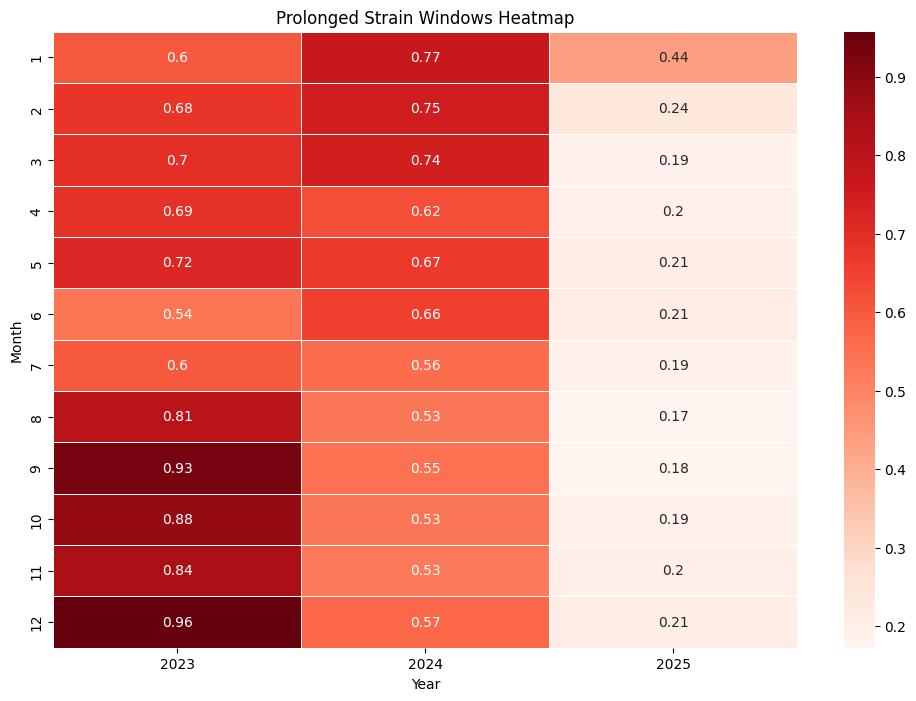

In [82]:
# Plot
plt.figure(figsize=(12,8))

sns.heatmap(heatmap_data,annot=True,cmap="Reds",linewidth=0.5)

plt.title("Prolonged Strain Windows Heatmap")
plt.show()

# Key Performance Indicators (KPIs)
KPI Name & Description
1. Total Children Under Care - System-wide responsibility
2. Net Intake Pressure - Inflow vs outflow imbalance
3. Care Load Volatility Index - Stability of system
4. Backlog Accumulation Rate - Sustained care pressure
5. Discharge Offset Ratio - Ability to relieve load

# 1. Total Children Under Care - System-wide responsibility

In [83]:
hs["Total_System_Load"]

2023-01-12    6619.0
2023-01-13    6619.0
2023-01-14    6619.0
2023-01-15    6619.0
2023-01-16    6619.0
               ...  
2025-12-17    2512.0
2025-12-18    2522.0
2025-12-19    2522.0
2025-12-20    2522.0
2025-12-21    2502.0
Freq: D, Name: Total_System_Load, Length: 1075, dtype: float64

# 2. Net Intake Pressure - Inflow vs outflow imbalance

In [84]:
hs["Net Daily Intake"]

2023-01-12   -402.0
2023-01-13      0.0
2023-01-14      0.0
2023-01-15      0.0
2023-01-16      0.0
              ...  
2025-12-17      1.0
2025-12-18    -10.0
2025-12-19      0.0
2025-12-20      0.0
2025-12-21     -3.0
Freq: D, Name: Net Daily Intake, Length: 1075, dtype: float64

# 3. Care Load Volatility Index - Stability of system

In [87]:
hs["Care_Load_Volatility_Index"] = (hs['Load_7d_std'] / hs['Load_7d_avg'])
hs["Care_Load_Volatility_Index"]

2023-01-12         NaN
2023-01-13         NaN
2023-01-14         NaN
2023-01-15         NaN
2023-01-16         NaN
                ...   
2025-12-17    0.006421
2025-12-18    0.006563
2025-12-19    0.005830
2025-12-20    0.003756
2025-12-21    0.003127
Freq: D, Name: Care_Load_Volatility_Index, Length: 1075, dtype: float64

# 4. Backlog Accumulation Rate - Sustained care pressure

In [90]:
hs["Backlog_Accumulation_Rate"] = ( hs['Net Daily Intake'].rolling(7).sum())
hs["Backlog_Accumulation_Rate"]

2023-01-12    NaN
2023-01-13    NaN
2023-01-14    NaN
2023-01-15    NaN
2023-01-16    NaN
             ... 
2025-12-17    4.0
2025-12-18   -5.0
2025-12-19   -5.0
2025-12-20   -5.0
2025-12-21   -4.0
Freq: D, Name: Backlog_Accumulation_Rate, Length: 1075, dtype: float64

# 5.Discharge Offset Ratio - Ability to relieve load

In [91]:
hs["Discharge_Offset_Ratio"] = hs["Discharges"] /hs["Transfers"]

In [92]:
hs["Discharge_Offset_Ratio"] 

2023-01-12    12.823529
2023-01-13          NaN
2023-01-14          NaN
2023-01-15          NaN
2023-01-16          NaN
                ...    
2025-12-17     0.909091
2025-12-18     2.666667
2025-12-19          NaN
2025-12-20          NaN
2025-12-21     1.272727
Freq: D, Name: Discharge_Offset_Ratio, Length: 1075, dtype: float64

In [93]:
hs.to_csv("Updated_HHS_Unaccompanied_Alien_Children_Program.csv", index=False)

In [94]:
hs.reset_index().to_csv("U_H_U_A_C_P.csv", index=False)